# Import Libraries

In [1]:
import pandas as pd


In [2]:
import numpy as np


In [3]:
import matplotlib.pyplot as plt


In [4]:
import seaborn as sns

## Load the Cleaned Dataset

In [5]:
df_long= pd.read_csv("../data/cleaned/world_bank_long_format.csv")
df_long.shape

(9015914, 6)

In [6]:
df_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Africa Eastern and Southern,AFE,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,135.792572
1,Africa Eastern and Southern,AFE,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,88.967790
2,Africa Eastern and Southern,AFE,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,5.631545
3,Africa Eastern and Southern,AFE,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,82.970097
4,Africa Eastern and Southern,AFE,Aquaculture production (metric tons),ER.FSH.AQUA.MT,1960,380.000000


In [7]:
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 9015914 entries, 0 to 9015913
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Country Name    str    
 1   Country Code    str    
 2   Indicator Name  str    
 3   Indicator Code  str    
 4   Year            int64  
 5   Value           float64
dtypes: float64(1), int64(1), str(4)
memory usage: 412.7 MB


In [8]:
gdp_2024=df_long[
    (df_long["Year"]==2024) & (df_long["Indicator Code"]=="NY.GDP.MKTP.CD")
].copy()

In [9]:
gdp_2024.shape

(247, 6)

In [10]:
gdp_2024.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
8784215,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2024,1.252564e+12
8784692,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,2024,7.373670e+11
8785100,Arab World,ARB,GDP (current US$),NY.GDP.MKTP.CD,2024,3.745044e+12
8785565,Caribbean small states,CSS,GDP (current US$),NY.GDP.MKTP.CD,2024,9.043430e+10
8785971,Central Europe and the Baltics,CEB,GDP (current US$),NY.GDP.MKTP.CD,2024,2.463135e+12


In [11]:
gdp_2024["GDP_Billion"] = gdp_2024["Value"]/1000000000

In [12]:
gdp_2024.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,GDP_Billion
8784215,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2024,1.252564e+12,1252.564135
8784692,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,2024,7.373670e+11,737.366967
8785100,Arab World,ARB,GDP (current US$),NY.GDP.MKTP.CD,2024,3.745044e+12,3745.043770
8785565,Caribbean small states,CSS,GDP (current US$),NY.GDP.MKTP.CD,2024,9.043430e+10,90.434300
8785971,Central Europe and the Baltics,CEB,GDP (current US$),NY.GDP.MKTP.CD,2024,2.463135e+12,2463.134866


In [13]:
gdp_2024[ ["Country Name","GDP_Billion"] ].head()

,Country Name,GDP_Billion
8784215,Africa Eastern and Southern,1252.564135
8784692,Africa Western and Central,737.366967
8785100,Arab World,3745.043770
8785565,Caribbean small states,90.434300
8785971,Central Europe and the Baltics,2463.134866


In [14]:
top_10_gdp = gdp_2024.sort_values("GDP_Billion", ascending=False).head(10)

In [15]:
top_10_gdp.shape

(10, 7)

In [16]:
top_10_gdp[ ["Country Name","GDP_Billion"] ]

,Country Name,GDP_Billion
8807304,World,111669.432109
8791567,High income,72182.761740
8801323,OECD members,68279.421598
8802672,Post-demographic dividend,63619.224251
8792603,IDA & IBRD total,43660.232632
8792088,IBRD only,40766.443407
8797219,Low & middle income,39490.940515
8800304,Middle income,38887.384674
8787026,East Asia & Pacific,32200.466782
8806755,Upper middle income,32044.776967


In [17]:
countries = pd.read_csv("../data/cleaned/countries.csv")

In [18]:
countries.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Region,Income Group
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,Latin America & Caribbean,High income
1,AFE,Africa Eastern and Southern,Africa Eastern and Southern,Africa Eastern and Southern,ZH,NaN,NaN,NaN
2,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Middle East & North Africa,Low income
3,AFW,Africa Western and Central,Africa Western and Central,Africa Western and Central,ZI,NaN,NaN,NaN
4,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,Sub-Saharan Africa,Lower middle income


In [19]:
countries.columns

Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Region', 'Income Group'],
      dtype='str')

## Merge GDP data with Country metadata

In [20]:
gdp_2024 = gdp_2024.merge(
    countries[["Country Code", "Short Name", "Region", "Income Group"]],
    on="Country Code",
    how="left"
)

In [21]:
gdp_2024 = gdp_2024[gdp_2024["Region"].notna()].copy()

In [22]:
top_10_gdp = gdp_2024.sort_values("GDP_Billion",ascending=False).head(10)

In [23]:
top_10_gdp[ ["Short Name", "GDP_Billion"] ]

,Short Name,GDP_Billion
238,United States,29298.013000
85,China,18729.668436
115,Germany,4685.592578
136,Japan,4190.008188
128,India,3760.813471
237,United Kingdom,3695.539514
110,France,3160.442622
134,Italy,2383.435562
80,Canada,2270.076190
197,Russian Federation,2186.462269


## First Chart

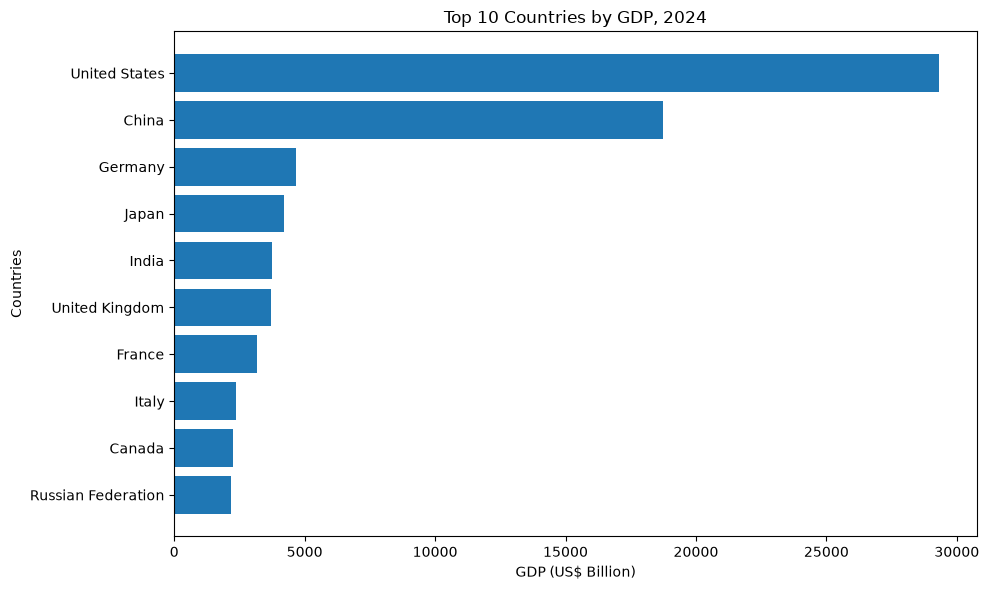

In [24]:
plt.figure(figsize=(10,6))
plt.barh(top_10_gdp["Short Name"][::-1], top_10_gdp["GDP_Billion"][::-1])
plt.xlabel("GDP (US$ Billion)")
plt.ylabel("Countries")
plt.title("Top 10 Countries by GDP, 2024")
plt.tight_layout()
plt.show()

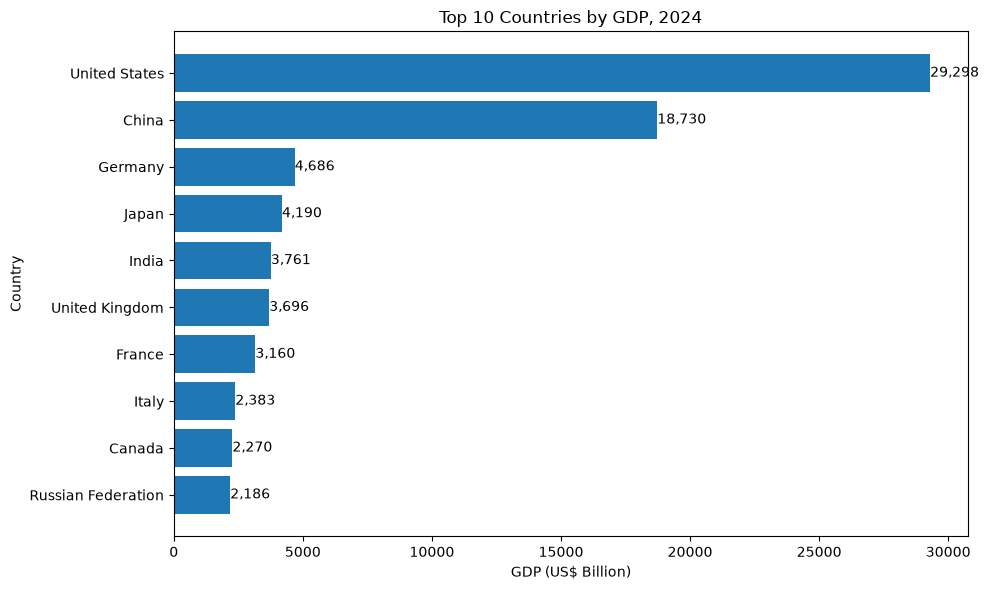

In [25]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10_gdp["Short Name"][::-1],
    top_10_gdp["GDP_Billion"][::-1]
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y()+ bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va = "center"
    )

plt.xlabel("GDP (US$ Billion)")
plt.ylabel("Country")
plt.title("Top 10 Countries by GDP, 2024")

plt.tight_layout()
plt.show()

### Key Insight

The United States had the largest GDP among the countries analysed in 2024, at approximately US$29.3 trillion, followed by China at US$18.7 trillion. There is a substantial gap between the two largest economies and the remaining countries in the top 10. India ranked fifth with GDP of approximately US$3.76 trillion.

In [26]:
india_gdp = df_long[
    (df_long["Country Code"] == "IND") & (df_long["Indicator Code"] == "NY.GDP.MKTP.CD")
].copy()

In [27]:
india_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
19482,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1960,3.702988e+10
59540,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1961,3.923244e+10
102734,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1962,4.216148e+10
146932,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1963,4.842192e+10
191867,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1964,5.648029e+10


In [28]:
india_gdp["GDP_Billion"] = india_gdp["Value"]/1000000000

In [29]:
india_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,GDP_Billion
19482,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1960,3.702988e+10,37.029884
59540,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1961,3.923244e+10,39.232436
102734,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1962,4.216148e+10,42.161482
146932,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1963,4.842192e+10,48.421923
191867,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1964,5.648029e+10,56.480290


In [30]:
india_gdp = india_gdp.sort_values("Year")

In [31]:
india_gdp[ ["Year", "GDP_Billion"] ].head(10)

,Year,GDP_Billion
19482,1960,37.029884
59540,1961,39.232436
102734,1962,42.161482
146932,1963,48.421923
191867,1964,56.480290
238076,1965,59.556105
285353,1966,45.581231
332932,1967,50.134942
381256,1968,53.085456
430201,1969,58.447995


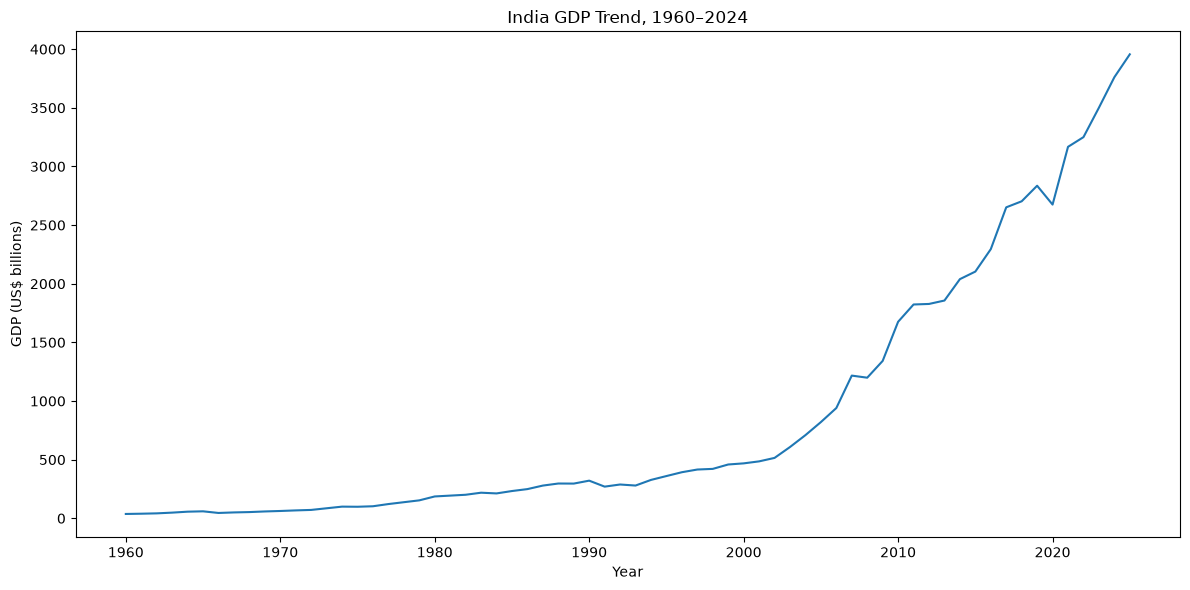

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_gdp["Year"],
    india_gdp["GDP_Billion"]
)

plt.xlabel("Year")
plt.ylabel("GDP (US$ billions)")
plt.title("India GDP Trend, 1960–2024")

plt.tight_layout()
plt.show()

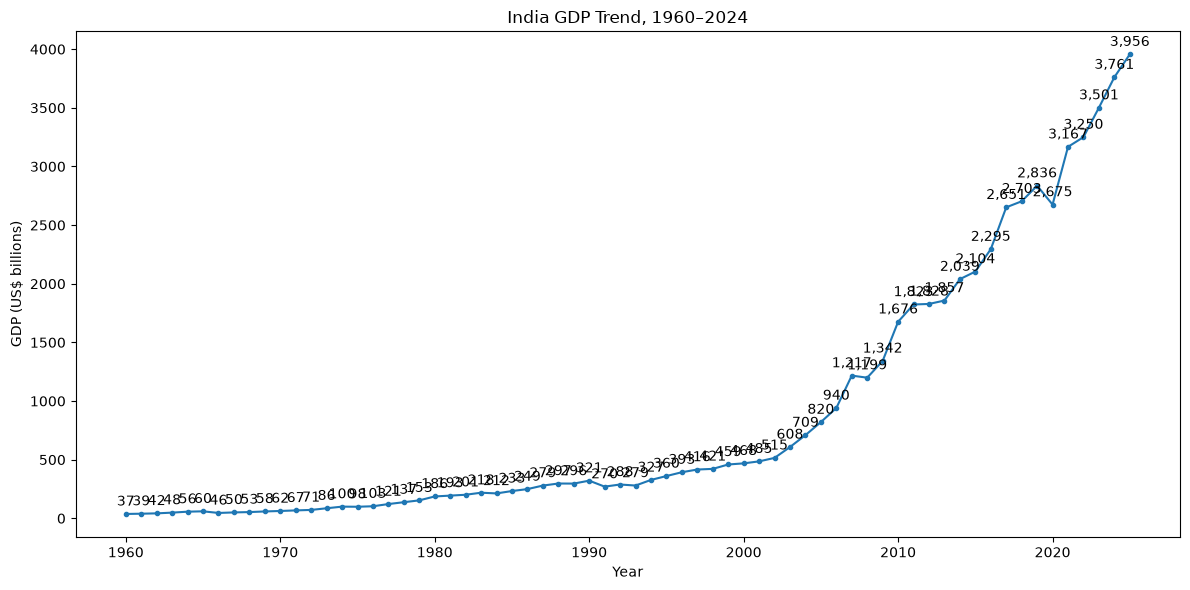

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_gdp["Year"],
    india_gdp["GDP_Billion"],
    marker="o",
    markersize=3
)

for x, y in zip(india_gdp["Year"], india_gdp["GDP_Billion"]):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Year")
plt.ylabel("GDP (US$ billions)")
plt.title("India GDP Trend, 1960–2024")

plt.tight_layout()
plt.show()

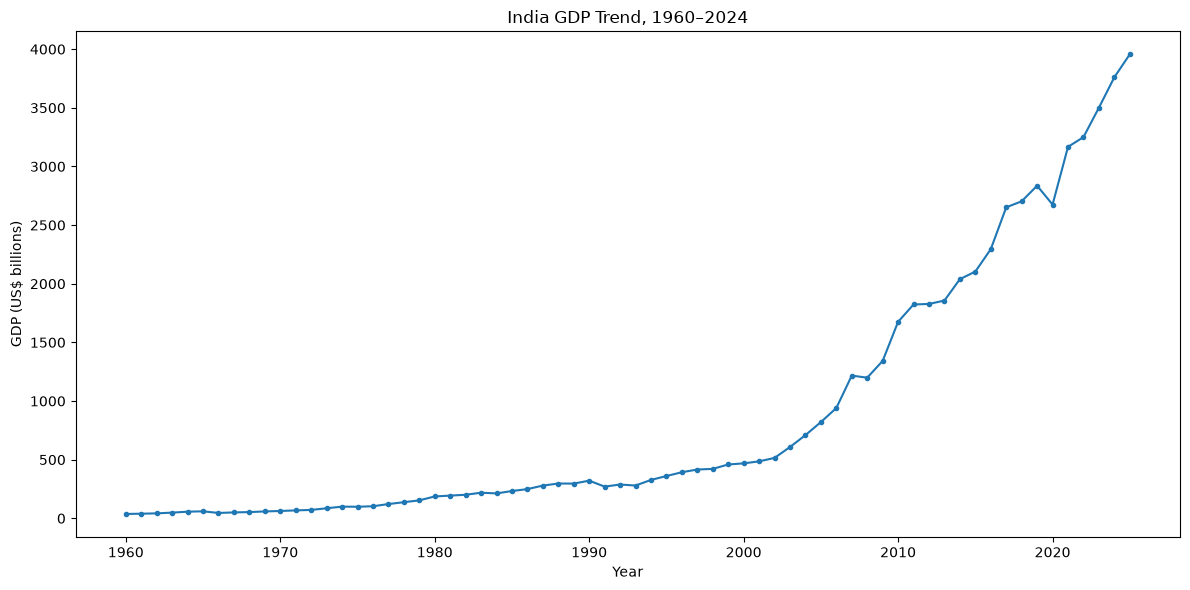

In [34]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_gdp["Year"],
    india_gdp["GDP_Billion"],
    marker="o",
    markersize=3
)

plt.xlabel("Year")
plt.ylabel("GDP (US$ billions)")
plt.title("India GDP Trend, 1960–2024")

plt.tight_layout()
plt.show()

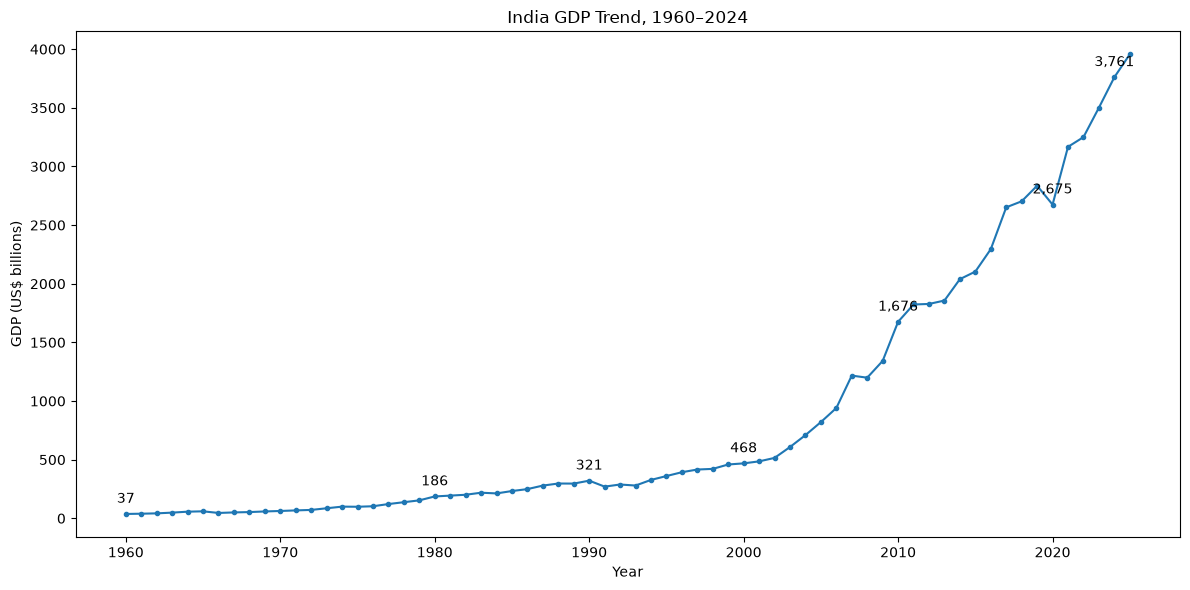

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_gdp["Year"],
    india_gdp["GDP_Billion"],
    marker="o",
    markersize=3
)

# Years we want to label
label_years = [1960, 1980, 1990, 2000, 2010, 2020, 2024]

for year in label_years:
    row = india_gdp[india_gdp["Year"] == year].iloc[0]
    
    plt.annotate(
        f"{row['GDP_Billion']:,.0f}",
        (row["Year"], row["GDP_Billion"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Year")
plt.ylabel("GDP (US$ billions)")
plt.title("India GDP Trend, 1960–2024")

plt.tight_layout()
plt.show()

In [36]:
india_gdp[["Year", "GDP_Billion"]]

,Year,GDP_Billion
19482,1960,37.029884
59540,1961,39.232436
102734,1962,42.161482
146932,1963,48.421923
191867,1964,56.480290
...,...,...
8297719,2021,3167.270623
8502112,2022,3249.938492
8692987,2023,3500.906031
8860072,2024,3760.813471


### Key Insight

India's nominal GDP increased substantially from approximately US$37 billion in 1960 to US$3.76 trillion in 2024. The long-term trend shows a marked acceleration in the pace of GDP expansion from the early 2000s onward, with a noticeable decline around 2020. As this measure is reported in current US dollars, changes reflect economic growth as well as inflation and exchange-rate movements.

# Calculate GDP growth rate

In [37]:
gdp_2023 = df_long[
    (df_long["Year"] == 2023) & (df_long["Indicator Code"]=="NY.GDP.MKTP.CD")
].copy()

gdp_2024 = df_long[
    (df_long["Year"] == 2024) & (df_long["Indicator Code"]=="NY.GDP.MKTP.CD")
].copy()

In [38]:
gdp_2023.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
8600081,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2023,1.179122e+12
8600669,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,2023,9.384807e+11
8601203,Arab World,ARB,GDP (current US$),NY.GDP.MKTP.CD,2023,3.617895e+12
8601763,Caribbean small states,CSS,GDP (current US$),NY.GDP.MKTP.CD,2023,7.959408e+10
8602252,Central Europe and the Baltics,CEB,GDP (current US$),NY.GDP.MKTP.CD,2023,2.273564e+12


In [39]:
gdp_growth = gdp_2023[
    ["Country Code", "Country Name", "Value"]
].merge(
    gdp_2024[["Country Code", "Value"]],
    on="Country Code",
    suffixes=("_2023", "_2024")
)

In [40]:
gdp_growth.head(20)

,Country Code,Country Name,Value_2023,Value_2024
0,AFE,Africa Eastern and Southern,1.179122e+12,1.252564e+12
1,AFW,Africa Western and Central,9.384807e+11,7.373670e+11
2,ARB,Arab World,3.617895e+12,3.745044e+12
3,CSS,Caribbean small states,7.959408e+10,9.043430e+10
4,CEB,Central Europe and the Baltics,2.273564e+12,2.463135e+12
5,EAR,Early-demographic dividend,1.479149e+13,1.564892e+13
6,EAS,East Asia & Pacific,3.159745e+13,3.220047e+13
7,EAP,East Asia & Pacific (excluding high income),2.164553e+13,2.224873e+13
8,TEA,East Asia & Pacific (IDA & IBRD countries),2.161880e+13,2.222130e+13
9,EMU,Euro area,1.595734e+13,1.660146e+13


In [41]:
gdp_growth["GDP_Growth_%"] = (
    (gdp_growth["Value_2024"] - gdp_growth["Value_2023"])
    / gdp_growth["Value_2023"]
) * 100

In [42]:
gdp_growth[ ["Country Name", "GDP_Growth_%"]].sort_values(
    "GDP_Growth_%", ascending=False).head(10)

,Country Name,GDP_Growth_%
122,Guyana,45.773617
147,Lebanon,29.349741
219,Suriname,27.185864
218,Sudan,24.497656
123,Haiti,23.928569
144,Kyrgyz Republic,19.635197
200,Sao Tome and Principe,19.485035
230,Turkiye,19.091546
214,Sri Lanka,18.477340
222,Tajikistan,17.812106


## Create top 10 dataset

In [43]:
top_10_growth = (gdp_growth.sort_values("GDP_Growth_%", ascending=False).head(10))

In [44]:
top_10_growth[["Country Name", "GDP_Growth_%"]]

,Country Name,GDP_Growth_%
122,Guyana,45.773617
147,Lebanon,29.349741
219,Suriname,27.185864
218,Sudan,24.497656
123,Haiti,23.928569
144,Kyrgyz Republic,19.635197
200,Sao Tome and Principe,19.485035
230,Turkiye,19.091546
214,Sri Lanka,18.477340
222,Tajikistan,17.812106


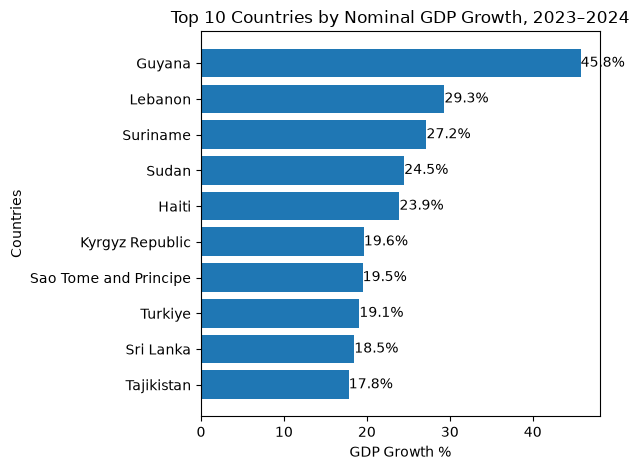

In [45]:
plt.Figure(figsize=(10,6))
bars = plt.barh(
    top_10_growth["Country Name"][::-1],
    top_10_growth["GDP_Growth_%"][::-1]
)
for i in bars:
    plt.text(
        i.get_width(),
        i.get_y() + i.get_height()/2,
        f"{i.get_width():.1f}%",
        va = "center"
    )

plt.xlabel("GDP Growth %")
plt.ylabel("Countries")
plt.title("Top 10 Countries by Nominal GDP Growth, 2023–2024")
plt.tight_layout()
plt.show()

### Key Insight

Guyana recorded the highest year-over-year increase in nominal GDP among the countries analysed, at approximately 45.8%, followed by Lebanon at 29.3% and Suriname at 27.2%. These figures represent changes in GDP measured in current US dollars and should not be interpreted as real GDP growth because inflation and exchange-rate movements can also influence the result.

# GDP trend comparison: India vs Australia vs New Zealand.

In [46]:
comparison_gdp = df_long[
    (df_long["Country Code"].isin(["IND", "AUS", "NZL"])) &
    (df_long["Indicator Code"] == "NY.GDP.MKTP.CD")
].copy()

In [47]:
comparison_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
8027,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1960,1.863568e+10
19482,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1960,3.702988e+10
26556,New Zealand,NZL,GDP (current US$),NY.GDP.MKTP.CD,1960,5.536098e+09
46397,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1961,1.971312e+10
59540,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1961,3.923244e+10


In [48]:
comparison_gdp["GDP_Billions"] = comparison_gdp["Value"]/1000000000

In [49]:
comparison_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,GDP_Billions
8027,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1960,1.863568e+10,18.635683
19482,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1960,3.702988e+10,37.029884
26556,New Zealand,NZL,GDP (current US$),NY.GDP.MKTP.CD,1960,5.536098e+09,5.536098
46397,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1961,1.971312e+10,19.713123
59540,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1961,3.923244e+10,39.232436


In [50]:
comparison_gdp = comparison_gdp.sort_values(["Country Code", "Year"])

In [51]:
comparison_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,GDP_Billions
8027,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1960,1.863568e+10,18.635683
46397,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1961,1.971312e+10,19.713123
89210,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1962,1.995392e+10,19.953923
133134,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1963,2.157344e+10,21.573443
177952,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1964,2.383584e+10,23.835844


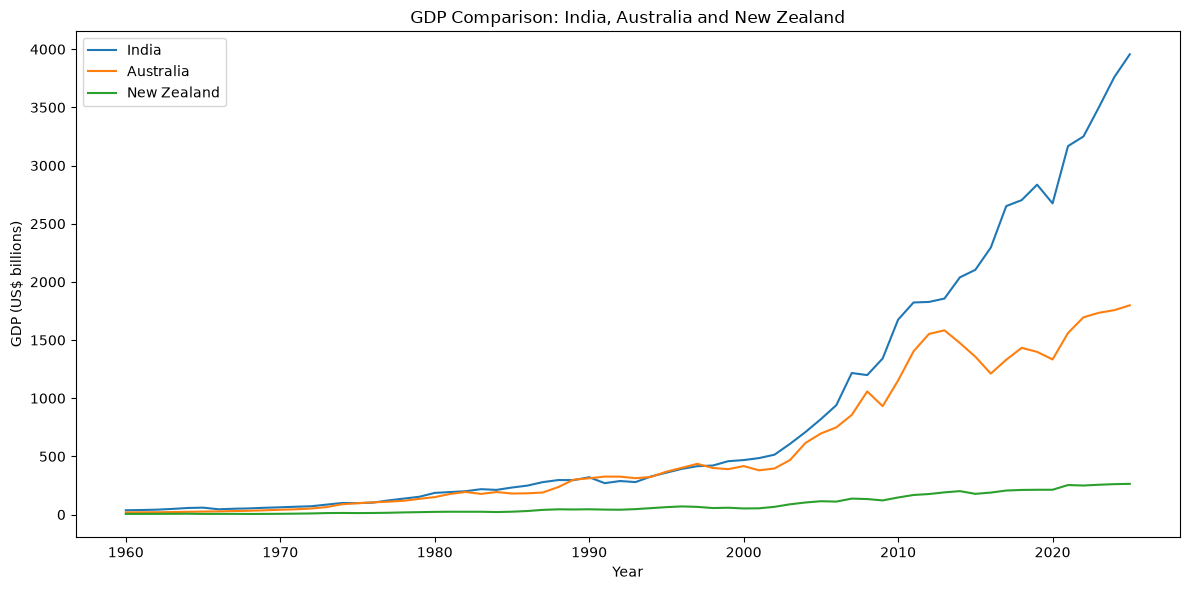

In [52]:
plt.figure(figsize=(12, 6))

for c in ["IND", "AUS", "NZL"]:
    
    country_data = comparison_gdp[comparison_gdp["Country Code"] == c]
    country_name = country_data["Country Name"].iloc[0]
    
    plt.plot(
        country_data["Year"],
        country_data["GDP_Billions"],
        label=country_name
    )

ax = plt.gca()

ax.set_xlabel("Year")
ax.set_ylabel("GDP (US$ billions)")
ax.set_title("GDP Comparison: India, Australia and New Zealand")

ax.legend()

plt.tight_layout()
plt.show()

# “How does average GDP differ across World Bank income groups?”

## Create the income-group dataset

In [53]:
gdp_2024.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
8784215,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2024,1.252564e+12
8784692,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,2024,7.373670e+11
8785100,Arab World,ARB,GDP (current US$),NY.GDP.MKTP.CD,2024,3.745044e+12
8785565,Caribbean small states,CSS,GDP (current US$),NY.GDP.MKTP.CD,2024,9.043430e+10
8785971,Central Europe and the Baltics,CEB,GDP (current US$),NY.GDP.MKTP.CD,2024,2.463135e+12


In [54]:
gdp_2024 = gdp_2024.merge(
    countries[["Country Code", "Income Group"]],
    on="Country Code",
    how="left"
)

In [55]:
gdp_2024.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Income Group
0,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2024,1.252564e+12,NaN
1,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,2024,7.373670e+11,NaN
2,Arab World,ARB,GDP (current US$),NY.GDP.MKTP.CD,2024,3.745044e+12,NaN
3,Caribbean small states,CSS,GDP (current US$),NY.GDP.MKTP.CD,2024,9.043430e+10,NaN
4,Central Europe and the Baltics,CEB,GDP (current US$),NY.GDP.MKTP.CD,2024,2.463135e+12,NaN


In [56]:
gdp_2024.loc[gdp_2024["Country Code"].isin(["IND", "AUS", "NZL"]),
["Country Name", "Country Code", "Income Group"]
]

,Country Name,Country Code,Income Group
56,Australia,AUS,High income
128,India,IND,Lower middle income
178,New Zealand,NZL,High income


In [57]:
gdp_2024["GDP_Billions"] = gdp_2024["Value"] / 1_000_000_000

In [58]:
gdp_2024.loc[
    gdp_2024["Country Code"].isin(["IND", "AUS", "NZL"]),
    ["Country Name", "Country Code", "GDP_Billions", "Income Group"]
]

,Country Name,Country Code,GDP_Billions,Income Group
56,Australia,AUS,1757.022452,High income
128,India,IND,3760.813471,Lower middle income
178,New Zealand,NZL,261.497198,High income


In [59]:
income_gdp = (
    gdp_2024
    .dropna(subset=["Income Group"])
    .groupby("Income Group", as_index=False)["GDP_Billions"]
    .mean()
)

In [60]:
income_gdp

,Income Group,GDP_Billions
0,High income,951.163246
1,Low income,26.861545
2,Lower middle income,145.625955
3,Upper middle income,550.032003


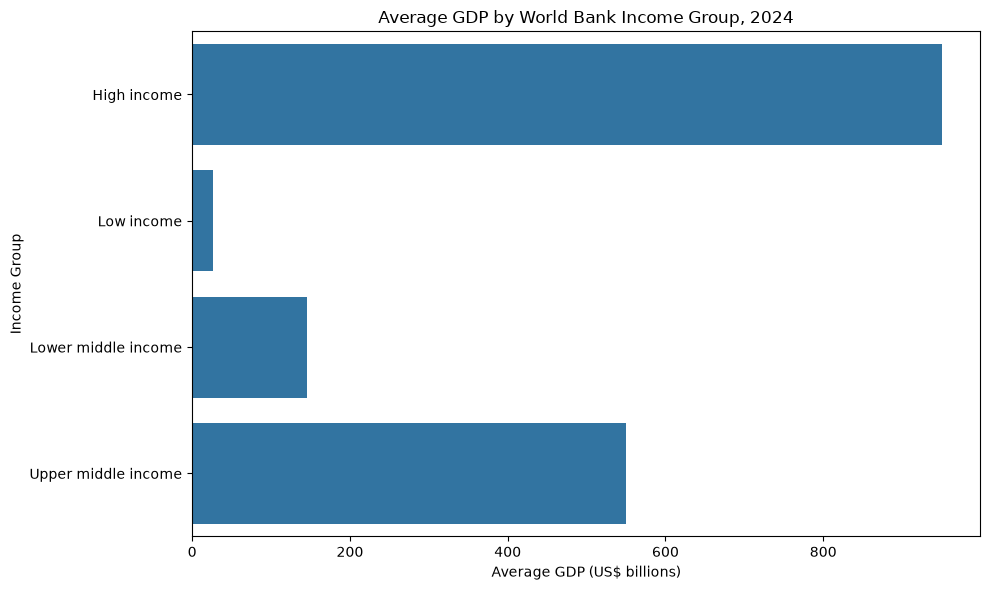

In [61]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=income_gdp,
    x="GDP_Billions",
    y="Income Group"
)

ax.set_xlabel("Average GDP (US$ billions)")
ax.set_ylabel("Income Group")
ax.set_title("Average GDP by World Bank Income Group, 2024")

plt.tight_layout()
plt.show()

In [62]:
india_gdp["GDP_3Y_Moving_Avg"] = (
    india_gdp["GDP_Billion"]
    .rolling(window=3)
    .mean()
)

In [63]:
india_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,GDP_Billion,GDP_3Y_Moving_Avg
19482,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1960,3.702988e+10,37.029884,NaN
59540,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1961,3.923244e+10,39.232436,NaN
102734,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1962,4.216148e+10,42.161482,39.474601
146932,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1963,4.842192e+10,48.421923,43.271947
191867,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1964,5.648029e+10,56.480290,49.021232


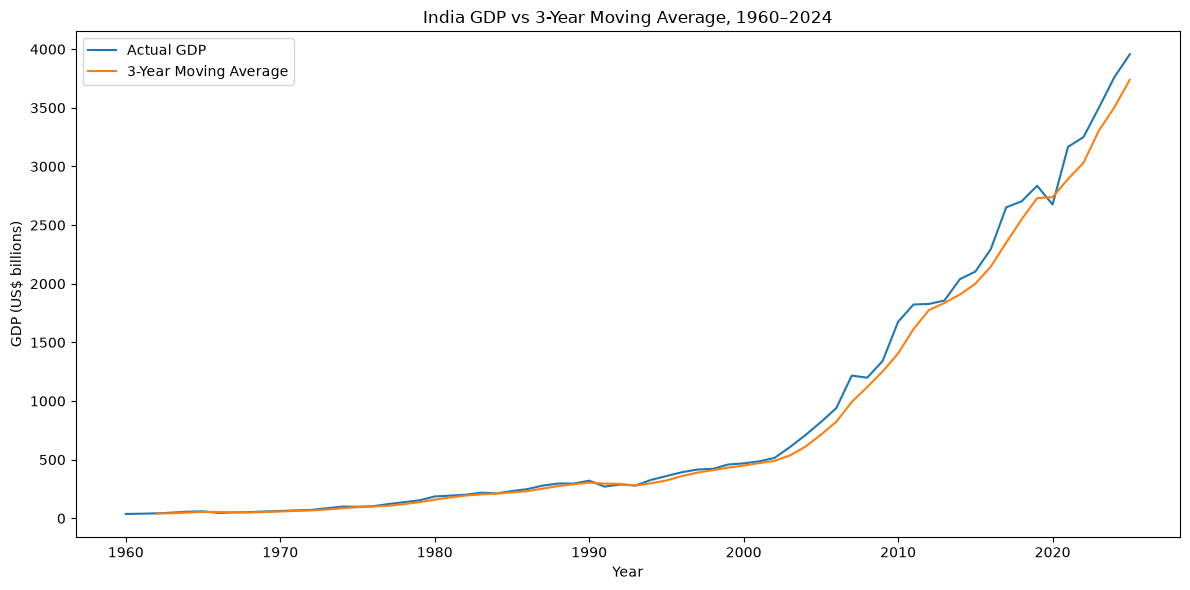

In [64]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_gdp["Year"],
    india_gdp["GDP_Billion"],
    label="Actual GDP"
)

plt.plot(
    india_gdp["Year"],
    india_gdp["GDP_3Y_Moving_Avg"],
    label="3-Year Moving Average"
)

plt.xlabel("Year")
plt.ylabel("GDP (US$ billions)")
plt.title("India GDP vs 3-Year Moving Average, 1960–2024")

plt.legend()
plt.tight_layout()
plt.show()

In [65]:
population_2024 = df_long[
    (df_long["Year"] == 2024) &
    (df_long["Indicator Code"] == "SP.POP.TOTL")
].copy()

In [66]:
population_2024.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
8784476,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,2024,769280888.0
8784897,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,2024,520655398.0
8785336,Arab World,ARB,"Population, total",SP.POP.TOTL,2024,492612632.0
8785752,Caribbean small states,CSS,"Population, total",SP.POP.TOTL,2024,4539060.0
8786227,Central Europe and the Baltics,CEB,"Population, total",SP.POP.TOTL,2024,100061963.0


In [67]:
population_2024.shape

(264, 6)

In [68]:
population_2024 = population_2024.merge(
    countries[["Country Code", "Short Name", "Region", "Income Group"]],
    on="Country Code",
    how="inner"
)

In [71]:
population_2024.head(15)

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Short Name,Region,Income Group
0,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,2024,7.692809e+08,Africa Eastern and Southern,NaN,NaN
1,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,2024,5.206554e+08,Africa Western and Central,NaN,NaN
2,Arab World,ARB,"Population, total",SP.POP.TOTL,2024,4.926126e+08,Arab World,NaN,NaN
3,Caribbean small states,CSS,"Population, total",SP.POP.TOTL,2024,4.539060e+06,Caribbean small states,NaN,NaN
4,Central Europe and the Baltics,CEB,"Population, total",SP.POP.TOTL,2024,1.000620e+08,Central Europe and the Baltics,NaN,NaN
5,Early-demographic dividend,EAR,"Population, total",SP.POP.TOTL,2024,3.552306e+09,Early-demographic dividend,NaN,NaN
6,East Asia & Pacific,EAS,"Population, total",SP.POP.TOTL,2024,2.388319e+09,East Asia & Pacific,NaN,NaN
7,East Asia & Pacific (excluding high income),EAP,"Population, total",SP.POP.TOTL,2024,2.141122e+09,East Asia & Pacific (excluding high income),NaN,NaN
8,East Asia & Pacific (IDA & IBRD countries),TEA,"Population, total",SP.POP.TOTL,2024,2.114653e+09,East Asia & Pacific (IDA & IBRD),NaN,NaN
9,Euro area,EMU,"Population, total",SP.POP.TOTL,2024,3.576034e+08,Euro area,NaN,NaN


In [70]:
population_2024.shape

(264, 9)

In [72]:
gdp_2024_scatter = gdp_2024[
    ["Country Code", "GDP_Billions"]
].copy()

In [73]:
gdp_2024_scatter.head()

,Country Code,GDP_Billions
0,AFE,1252.564135
1,AFW,737.366967
2,ARB,3745.043770
3,CSS,90.434300
4,CEB,2463.134866


In [74]:
# Now we can attach each country's GDP to its population record:
population_gdp = population_2024.merge(
    gdp_2024_scatter,
    on="Country Code",
    how="inner"
)

In [75]:
population_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Short Name,Region,Income Group,GDP_Billions
0,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,2024,769280888.0,Africa Eastern and Southern,NaN,NaN,1252.564135
1,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,2024,520655398.0,Africa Western and Central,NaN,NaN,737.366967
2,Arab World,ARB,"Population, total",SP.POP.TOTL,2024,492612632.0,Arab World,NaN,NaN,3745.043770
3,Caribbean small states,CSS,"Population, total",SP.POP.TOTL,2024,4539060.0,Caribbean small states,NaN,NaN,90.434300
4,Central Europe and the Baltics,CEB,"Population, total",SP.POP.TOTL,2024,100061963.0,Central Europe and the Baltics,NaN,NaN,2463.134866


In [ ]:
# Remove World Bank Aggregates & Null Region:
population_gdp = population_gdp[
    population_gdp["Region"].notna()
].copy()

In [77]:
population_gdp.shape

(200, 10)

In [78]:
population_gdp.head(10)

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Short Name,Region,Income Group,GDP_Billions
47,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2024,42647492.0,Afghanistan,Middle East & North Africa,Low income,17.778509
48,Albania,ALB,"Population, total",SP.POP.TOTL,2024,2377128.0,Albania,Europe & Central Asia,Upper middle income,27.037474
49,Algeria,DZA,"Population, total",SP.POP.TOTL,2024,46814308.0,Algeria,Middle East & North Africa,Upper middle income,269.322282
50,Andorra,AND,"Population, total",SP.POP.TOTL,2024,81938.0,Andorra,Europe & Central Asia,High income,4.044250
51,Angola,AGO,"Population, total",SP.POP.TOTL,2024,37885849.0,Angola,Sub-Saharan Africa,Lower middle income,103.080538
52,Antigua and Barbuda,ATG,"Population, total",SP.POP.TOTL,2024,93772.0,Antigua and Barbuda,Latin America & Caribbean,High income,2.162367
53,Argentina,ARG,"Population, total",SP.POP.TOTL,2024,45696159.0,Argentina,Latin America & Caribbean,Upper middle income,638.365455
54,Armenia,ARM,"Population, total",SP.POP.TOTL,2024,3033500.0,Armenia,Europe & Central Asia,Upper middle income,25.955275
55,Aruba,ABW,"Population, total",SP.POP.TOTL,2024,107995.0,Aruba,Latin America & Caribbean,High income,4.167588
56,Australia,AUS,"Population, total",SP.POP.TOTL,2024,27194286.0,Australia,East Asia & Pacific,High income,1757.022452


In [79]:
# Convert population to millions
population_gdp["Population_Millions"] = (
    population_gdp["Value"] / 1_000_000
)

In [80]:
population_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Short Name,Region,Income Group,GDP_Billions,Population_Millions
47,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2024,42647492.0,Afghanistan,Middle East & North Africa,Low income,17.778509,42.647492
48,Albania,ALB,"Population, total",SP.POP.TOTL,2024,2377128.0,Albania,Europe & Central Asia,Upper middle income,27.037474,2.377128
49,Algeria,DZA,"Population, total",SP.POP.TOTL,2024,46814308.0,Algeria,Middle East & North Africa,Upper middle income,269.322282,46.814308
50,Andorra,AND,"Population, total",SP.POP.TOTL,2024,81938.0,Andorra,Europe & Central Asia,High income,4.044250,0.081938
51,Angola,AGO,"Population, total",SP.POP.TOTL,2024,37885849.0,Angola,Sub-Saharan Africa,Lower middle income,103.080538,37.885849


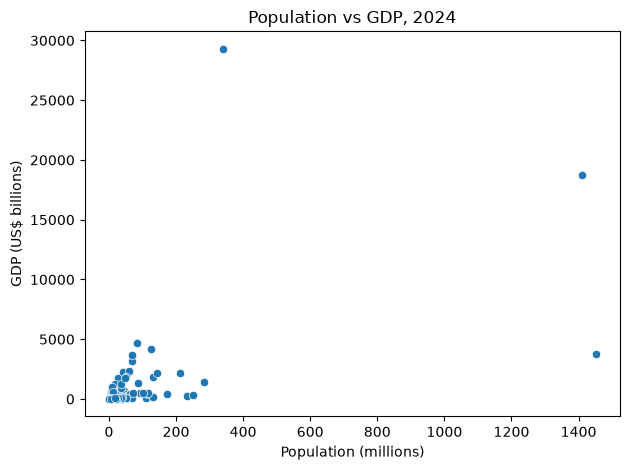

In [81]:
sns.scatterplot(
    data=population_gdp,
    x="Population_Millions",
    y="GDP_Billions"
)

plt.xlabel("Population (millions)")
plt.ylabel("GDP (US$ billions)")
plt.title("Population vs GDP, 2024")

plt.tight_layout()
plt.show()

In [ ]:
# Install SCIPY in .venv
from scipy.stats import pearsonr

In [84]:
correlation, p_value = pearsonr(
    population_gdp["Population_Millions"],
    population_gdp["GDP_Billions"]
)

In [85]:
print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.5570424035337534
P-value: 1.071684574761201e-17


### Means there is a moderate positive linear relationship between population and GDP in your 2024 country-level data.
### Countries with larger populations tend to have larger GDPs, but population alone does not explain GDP very strongly.

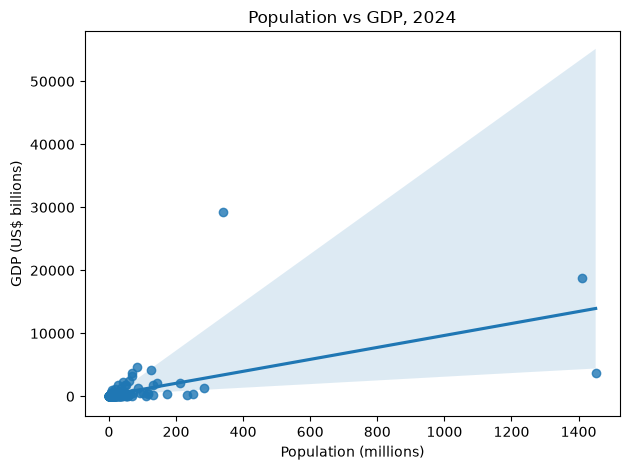

In [86]:
sns.regplot(
    data=population_gdp,
    x="Population_Millions",
    y="GDP_Billions"
)

plt.xlabel("Population (millions)")
plt.ylabel("GDP (US$ billions)")
plt.title("Population vs GDP, 2024")

plt.tight_layout()
plt.show()

In [90]:
# 10 most populous countries and their GDP

population_gdp.nlargest(10, "Population_Millions")[["Country Name", "Population_Millions", "GDP_Billions"]]

,Country Name,Population_Millions,GDP_Billions
128,India,1450.935791,3760.813471
85,China,1408.975000,18729.668436
238,United States,340.003797,29298.013000
129,Indonesia,283.487931,1396.301788
185,Pakistan,251.269164,371.747088
181,Nigeria,232.679478,252.261880
72,Brazil,211.998573,2185.821611
61,Bangladesh,173.562364,450.119432
197,Russian Federation,143.669648,2186.462269
106,Ethiopia,132.059767,149.740298


In [91]:
population_gdp

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Short Name,Region,Income Group,GDP_Billions,Population_Millions
47,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2024,42647492.0,Afghanistan,Middle East & North Africa,Low income,17.778509,42.647492
48,Albania,ALB,"Population, total",SP.POP.TOTL,2024,2377128.0,Albania,Europe & Central Asia,Upper middle income,27.037474,2.377128
49,Algeria,DZA,"Population, total",SP.POP.TOTL,2024,46814308.0,Algeria,Middle East & North Africa,Upper middle income,269.322282,46.814308
50,Andorra,AND,"Population, total",SP.POP.TOTL,2024,81938.0,Andorra,Europe & Central Asia,High income,4.044250,0.081938
51,Angola,AGO,"Population, total",SP.POP.TOTL,2024,37885849.0,Angola,Sub-Saharan Africa,Lower middle income,103.080538,37.885849
...,...,...,...,...,...,...,...,...,...,...,...
242,"Venezuela, RB",VEN,"Population, total",SP.POP.TOTL,2024,28405543.0,"Venezuela, República Bolivariana de",Latin America & Caribbean,Lower middle income,120.566112,28.405543
243,Viet Nam,VNM,"Population, total",SP.POP.TOTL,2024,100987686.0,Viet Nam,East Asia & Pacific,Upper middle income,476.324573,100.987686
244,West Bank and Gaza,PSE,"Population, total",SP.POP.TOTL,2024,5289152.0,West Bank and Gaza,Middle East & North Africa,Lower middle income,16.016900,5.289152
245,Zambia,ZMB,"Population, total",SP.POP.TOTL,2024,21314956.0,Zambia,Sub-Saharan Africa,Lower middle income,25.303185,21.314956


In [92]:
population_gdp["GDP_Per_Capita"] = (
    population_gdp["GDP_Billions"] * 1_000_000_000
    / (population_gdp["Population_Millions"] * 1_000_000)
)

In [93]:
population_gdp[
    ["Country Name", "Population_Millions", "GDP_Billions", "GDP_Per_Capita"]
].head()

,Country Name,Population_Millions,GDP_Billions,GDP_Per_Capita
47,Afghanistan,42.647492,17.778509,416.871146
48,Albania,2.377128,27.037474,11374.008578
49,Algeria,46.814308,269.322282,5752.990767
50,Andorra,0.081938,4.044250,49357.437070
51,Angola,37.885849,103.080538,2720.819007


In [94]:
population_gdp.nlargest(
    10,
    "GDP_Per_Capita"
)[
    ["Country Name", "GDP_Per_Capita"]
]

,Country Name,GDP_Per_Capita
167,Monaco,288001.574856
151,Liechtenstein,220167.225474
67,Bermuda,142250.433195
153,Luxembourg,137781.681659
132,Ireland,112894.953241
221,Switzerland,107702.065940
81,Cayman Islands,104292.900672
206,Singapore,94896.562150
183,Norway,89888.953520
238,United States,86169.664158


In [101]:
population_gdp.groupby("Income Group")["GDP_Per_Capita"].mean().sort_values(ascending=False)

Income Group
High income            51147.767611
Upper middle income     8422.518569
Lower middle income     2584.606948
Low income               788.594520
Name: GDP_Per_Capita, dtype: float64

In [102]:
population_gdp.groupby("Income Group")["GDP_Per_Capita"].mean().sort_values(ascending=False).round(2)

Income Group
High income            51147.77
Upper middle income     8422.52
Lower middle income     2584.61
Low income               788.59
Name: GDP_Per_Capita, dtype: float64

In [103]:
income_pc = (
    population_gdp
    .groupby("Income Group")["GDP_Per_Capita"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

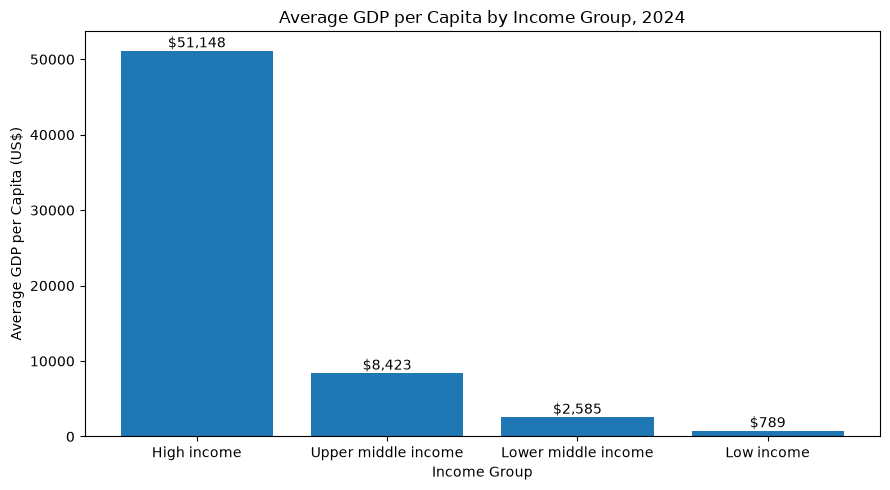

In [104]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    income_pc.index,
    income_pc.values
)

plt.xlabel("Income Group")
plt.ylabel("Average GDP per Capita (US$)")
plt.title("Average GDP per Capita by Income Group, 2024")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### HEATMAP: Let's start by seeing the exact indicator names available for:
•	GDP 
•	Population 
•	Life expectancy 
•	Unemployment 
•	Internet usage


In [105]:
df_long[
    df_long["Indicator Name"].str.contains(
        "life expectancy|unemployment|internet",
        case=False,
        na=False
    )
][
    ["Indicator Name", "Indicator Code"]
].drop_duplicates().head(50)

,Indicator Name,Indicator Code
20,"Life expectancy at birth, female (years)",SP.DYN.LE00.FE.IN
21,"Life expectancy at birth, male (years)",SP.DYN.LE00.MA.IN
22,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN
4918,"Unemployment, youth female (% of female labor ...",SL.UEM.1524.FE.NE.ZS
4919,"Unemployment, youth male (% of male labor forc...",SL.UEM.1524.MA.NE.ZS
4920,"Unemployment, youth total (% of total labor fo...",SL.UEM.1524.NE.ZS
21233,"Unemployment, female (% of female labor force)...",SL.UEM.TOTL.FE.NE.ZS
21234,"Unemployment, male (% of male labor force) (na...",SL.UEM.TOTL.MA.NE.ZS
21235,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS
500932,Unemployment with advanced education (% of tot...,SL.UEM.ADVN.ZS


In [106]:
life_expectancy_2024 = df_long[
    (df_long["Year"] == 2024) &
    (df_long["Indicator Code"] == "SP.DYN.LE00.IN")
].copy()

In [110]:
life_expectancy_2024

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
8784324,Africa Eastern and Southern,AFE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,65.349930
8784754,Africa Western and Central,AFW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,59.041538
8785197,Arab World,ARB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,72.721805
8785627,Caribbean small states,CSS,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,73.312667
8786086,Central Europe and the Baltics,CEB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,77.918095
...,...,...,...,...,...,...
8931836,Virgin Islands (U.S.),VIR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,80.770732
8932261,West Bank and Gaza,PSE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,69.213000
8932624,"Yemen, Rep.",YEM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,69.439000
8933166,Zambia,ZMB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,66.528000


### Keep only actual countries

In [111]:
life_expectancy_2024 = life_expectancy_2024.merge(
    countries[["Country Code", "Region"]],
    on="Country Code",
    how="inner"
)

In [112]:
life_expectancy_2024 = life_expectancy_2024[
    life_expectancy_2024["Region"].notna()
].copy()

In [113]:
life_expectancy_2024.shape

(217, 7)

In [114]:
life_expectancy_2024

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Region
47,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,66.289000,Middle East & North Africa
48,Albania,ALB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,79.776000,Europe & Central Asia
49,Algeria,DZA,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,76.475000,Middle East & North Africa
50,American Samoa,ASM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,72.992000,East Asia & Pacific
51,Andorra,AND,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,84.188000,Europe & Central Asia
...,...,...,...,...,...,...,...
259,Virgin Islands (U.S.),VIR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,80.770732,Latin America & Caribbean
260,West Bank and Gaza,PSE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,69.213000,Middle East & North Africa
261,"Yemen, Rep.",YEM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,69.439000,Middle East & North Africa
262,Zambia,ZMB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,66.528000,Sub-Saharan Africa


In [115]:
internet_2024 = df_long[
    (df_long["Year"] == 2024) &
    (df_long["Indicator Code"] == "IT.NET.USER.ZS")
].copy()

In [116]:
internet_2024

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
8784291,Africa Eastern and Southern,AFE,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,28.800000
8784723,Africa Western and Central,AFW,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,40.000000
8787082,East Asia & Pacific,EAS,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,86.600000
8787576,East Asia & Pacific (excluding high income),EAP,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,86.100000
8788073,East Asia & Pacific (IDA & IBRD countries),TEA,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,86.800000
...,...,...,...,...,...,...
8929716,Uzbekistan,UZB,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,89.505501
8930857,"Venezuela, RB",VEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,76.678902
8931398,Viet Nam,VNM,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,84.150000
8933117,Zambia,ZMB,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,17.101000


In [117]:
internet_2024 = internet_2024.merge(
    countries[["Country Code", "Region"]],
    on="Country Code",
    how="inner"
)

In [118]:
internet_2024

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Region
0,Africa Eastern and Southern,AFE,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,28.800000,NaN
1,Africa Western and Central,AFW,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,40.000000,NaN
2,East Asia & Pacific,EAS,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,86.600000,NaN
3,East Asia & Pacific (excluding high income),EAP,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,86.100000,NaN
4,East Asia & Pacific (IDA & IBRD countries),TEA,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,86.800000,NaN
...,...,...,...,...,...,...,...
209,Uzbekistan,UZB,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,89.505501,Europe & Central Asia
210,"Venezuela, RB",VEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,76.678902,Latin America & Caribbean
211,Viet Nam,VNM,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,84.150000,East Asia & Pacific
212,Zambia,ZMB,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,17.101000,Sub-Saharan Africa


In [119]:
internet_2024 = internet_2024[
    internet_2024["Region"].notna()
].copy()

In [120]:
internet_2024

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Region
32,Afghanistan,AFG,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,16.094999,Middle East & North Africa
33,Albania,ALB,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,85.863899,Europe & Central Asia
34,Algeria,DZA,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,77.417801,Middle East & North Africa
35,Andorra,AND,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,94.397598,Europe & Central Asia
36,Angola,AGO,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,40.704800,Sub-Saharan Africa
...,...,...,...,...,...,...,...
209,Uzbekistan,UZB,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,89.505501,Europe & Central Asia
210,"Venezuela, RB",VEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,76.678902,Latin America & Caribbean
211,Viet Nam,VNM,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,84.150000,East Asia & Pacific
212,Zambia,ZMB,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,17.101000,Sub-Saharan Africa


In [121]:
internet_2024["Value"].isna().sum()

np.int64(0)

In [122]:
internet_2024.shape

(182, 7)

In [123]:
internet_lookup = internet_2024[
    ["Country Code", "Value"]
].copy()

In [124]:
internet_lookup

,Country Code,Value
32,AFG,16.094999
33,ALB,85.863899
34,DZA,77.417801
35,AND,94.397598
36,AGO,40.704800
...,...,...
209,UZB,89.505501
210,VEN,76.678902
211,VNM,84.150000
212,ZMB,17.101000


### Merge the above table with Population_GDP

In [125]:
population_gdp = population_gdp.merge(
    internet_lookup,
    on="Country Code",
    how="inner"
)

In [126]:
population_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value_x,Short Name,Region,Income Group,GDP_Billions,Population_Millions,GDP_Per_Capita,Value_y
0,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2024,42647492.0,Afghanistan,Middle East & North Africa,Low income,17.778509,42.647492,416.871146,16.094999
1,Albania,ALB,"Population, total",SP.POP.TOTL,2024,2377128.0,Albania,Europe & Central Asia,Upper middle income,27.037474,2.377128,11374.008578,85.863899
2,Algeria,DZA,"Population, total",SP.POP.TOTL,2024,46814308.0,Algeria,Middle East & North Africa,Upper middle income,269.322282,46.814308,5752.990767,77.417801
3,Andorra,AND,"Population, total",SP.POP.TOTL,2024,81938.0,Andorra,Europe & Central Asia,High income,4.044250,0.081938,49357.437070,94.397598
4,Angola,AGO,"Population, total",SP.POP.TOTL,2024,37885849.0,Angola,Sub-Saharan Africa,Lower middle income,103.080538,37.885849,2720.819007,40.704800


In [127]:
population_gdp = population_gdp.rename(
    columns={
        "Value_x": "Population",
        "Value_y": "Internet_Usage"
    }
)

In [128]:
population_gdp

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Population,Short Name,Region,Income Group,GDP_Billions,Population_Millions,GDP_Per_Capita,Internet_Usage
0,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2024,42647492.0,Afghanistan,Middle East & North Africa,Low income,17.778509,42.647492,416.871146,16.094999
1,Albania,ALB,"Population, total",SP.POP.TOTL,2024,2377128.0,Albania,Europe & Central Asia,Upper middle income,27.037474,2.377128,11374.008578,85.863899
2,Algeria,DZA,"Population, total",SP.POP.TOTL,2024,46814308.0,Algeria,Middle East & North Africa,Upper middle income,269.322282,46.814308,5752.990767,77.417801
3,Andorra,AND,"Population, total",SP.POP.TOTL,2024,81938.0,Andorra,Europe & Central Asia,High income,4.044250,0.081938,49357.437070,94.397598
4,Angola,AGO,"Population, total",SP.POP.TOTL,2024,37885849.0,Angola,Sub-Saharan Africa,Lower middle income,103.080538,37.885849,2720.819007,40.704800
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Uzbekistan,UZB,"Population, total",SP.POP.TOTL,2024,36361859.0,Uzbekistan,Europe & Central Asia,Lower middle income,121.356065,36.361859,3337.454921,89.505501
176,"Venezuela, RB",VEN,"Population, total",SP.POP.TOTL,2024,28405543.0,"Venezuela, República Bolivariana de",Latin America & Caribbean,Lower middle income,120.566112,28.405543,4244.457231,76.678902
177,Viet Nam,VNM,"Population, total",SP.POP.TOTL,2024,100987686.0,Viet Nam,East Asia & Pacific,Upper middle income,476.324573,100.987686,4716.659938,84.150000
178,Zambia,ZMB,"Population, total",SP.POP.TOTL,2024,21314956.0,Zambia,Sub-Saharan Africa,Lower middle income,25.303185,21.314956,1187.109434,17.101000


In [129]:
population_gdp[
    ["Country Name", "Population", "GDP_Billions", "GDP_Per_Capita", "Internet_Usage"]
].head()

,Country Name,Population,GDP_Billions,GDP_Per_Capita,Internet_Usage
0,Afghanistan,42647492.0,17.778509,416.871146,16.094999
1,Albania,2377128.0,27.037474,11374.008578,85.863899
2,Algeria,46814308.0,269.322282,5752.990767,77.417801
3,Andorra,81938.0,4.044250,49357.437070,94.397598
4,Angola,37885849.0,103.080538,2720.819007,40.704800


In [130]:
population_gdp = population_gdp.merge(
    life_expectancy_2024[["Country Code", "Value"]],
    on="Country Code",
    how="inner"
)

In [131]:
population_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Population,Short Name,Region,Income Group,GDP_Billions,Population_Millions,GDP_Per_Capita,Internet_Usage,Value
0,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2024,42647492.0,Afghanistan,Middle East & North Africa,Low income,17.778509,42.647492,416.871146,16.094999,66.289
1,Albania,ALB,"Population, total",SP.POP.TOTL,2024,2377128.0,Albania,Europe & Central Asia,Upper middle income,27.037474,2.377128,11374.008578,85.863899,79.776
2,Algeria,DZA,"Population, total",SP.POP.TOTL,2024,46814308.0,Algeria,Middle East & North Africa,Upper middle income,269.322282,46.814308,5752.990767,77.417801,76.475
3,Andorra,AND,"Population, total",SP.POP.TOTL,2024,81938.0,Andorra,Europe & Central Asia,High income,4.044250,0.081938,49357.437070,94.397598,84.188
4,Angola,AGO,"Population, total",SP.POP.TOTL,2024,37885849.0,Angola,Sub-Saharan Africa,Lower middle income,103.080538,37.885849,2720.819007,40.704800,64.805


In [132]:
population_gdp = population_gdp.rename(
    columns={
        "Value": "Life_Expectancy"
    }
)

In [133]:
population_gdp[
    [
        "Country Name",
        "Population",
        "GDP_Billions",
        "GDP_Per_Capita",
        "Internet_Usage",
        "Life_Expectancy"
    ]
].head()

,Country Name,Population,GDP_Billions,GDP_Per_Capita,Internet_Usage,Life_Expectancy
0,Afghanistan,42647492.0,17.778509,416.871146,16.094999,66.289
1,Albania,2377128.0,27.037474,11374.008578,85.863899,79.776
2,Algeria,46814308.0,269.322282,5752.990767,77.417801,76.475
3,Andorra,81938.0,4.044250,49357.437070,94.397598,84.188
4,Angola,37885849.0,103.080538,2720.819007,40.704800,64.805


In [134]:
population_gdp[
    [
        "Population",
        "GDP_Billions",
        "GDP_Per_Capita",
        "Internet_Usage",
        "Life_Expectancy"
    ]
].isna().sum()

Population         0
GDP_Billions       0
GDP_Per_Capita     0
Internet_Usage     0
Life_Expectancy    0
dtype: int64

## Create Matrix